In [18]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [5]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
df = pd.read_excel('../data/Data_Train.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing value counts:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget (Price) summary statistics:\n")
print(df['Price'].describe())

Data types:

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

Missing value counts:

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate rows: 220

Target (Price) summary statistics:

count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64


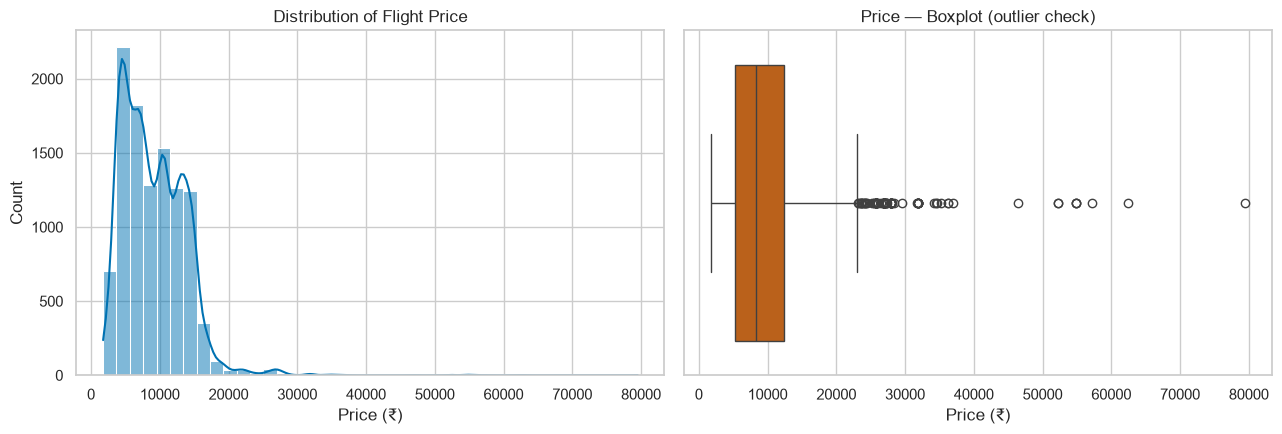

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Price'], bins=40, kde=True, ax=axes[0], color='#0072B2')
axes[0].set_title('Distribution of Flight Price')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')

sns.boxplot(x=df['Price'], ax=axes[1], color='#D55E00')
axes[1].set_title('Price — Boxplot (outlier check)')
axes[1].set_xlabel('Price (₹)')
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

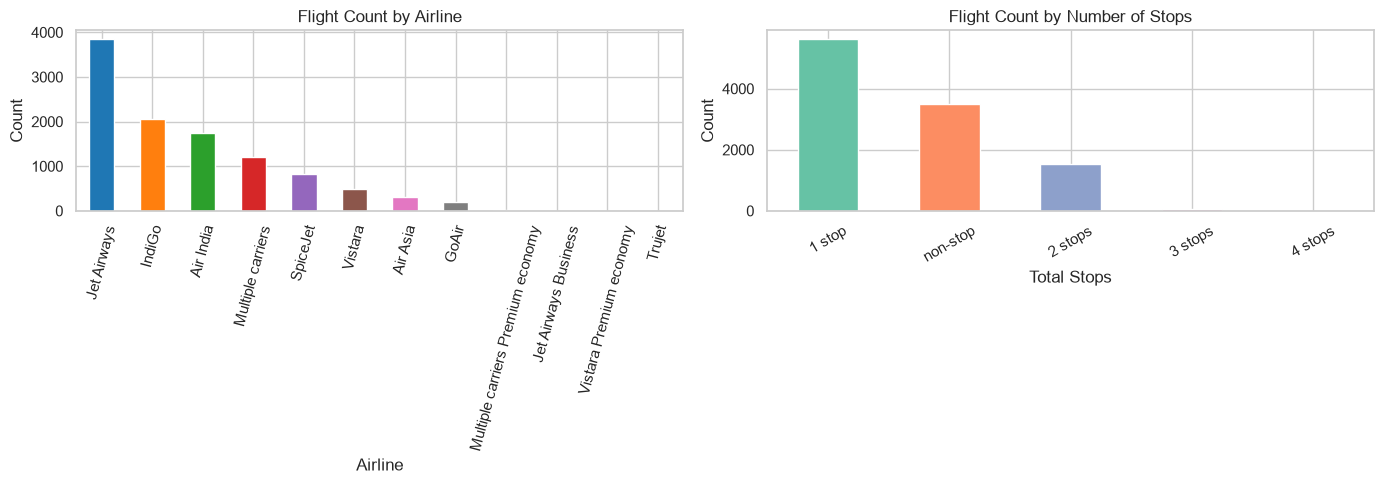

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Airline'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('tab10'))
axes[0].set_title('Flight Count by Airline')
axes[0].set_xlabel('Airline'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=75)

df['Total_Stops'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Flight Count by Number of Stops')
axes[1].set_xlabel('Total Stops'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight', dpi=100)
plt.show()

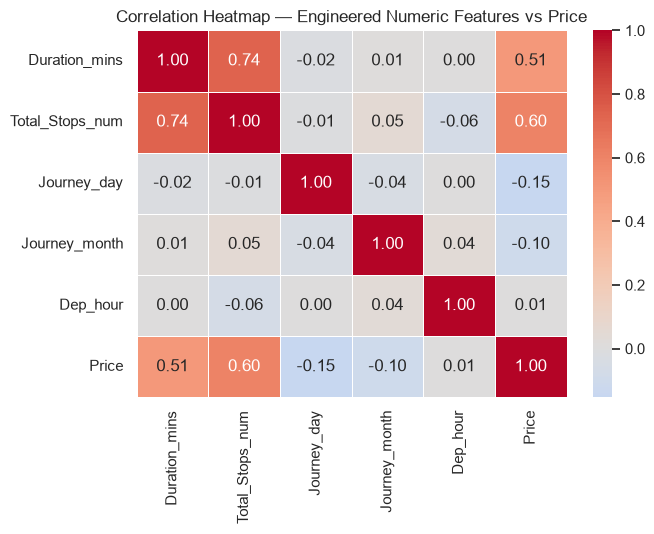

In [10]:
eda = df.copy()
eda['Duration_mins'] = eda['Duration'].str.replace('h', '*60').str.replace('m', '*1').str.replace(' ', '+').apply(lambda x: eval(x) if isinstance(x, str) else np.nan)
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
eda['Total_Stops_num'] = eda['Total_Stops'].map(stop_map)
eda['Journey_day'] = pd.to_datetime(eda['Date_of_Journey'], format='%d/%m/%Y').dt.day
eda['Journey_month'] = pd.to_datetime(eda['Date_of_Journey'], format='%d/%m/%Y').dt.month
eda['Dep_hour'] = pd.to_datetime(eda['Dep_Time'], format='%H:%M').dt.hour

corr_cols = ['Duration_mins', 'Total_Stops_num', 'Journey_day', 'Journey_month', 'Dep_hour', 'Price']
plt.figure(figsize=(7, 5.5))
sns.heatmap(eda[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Engineered Numeric Features vs Price')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

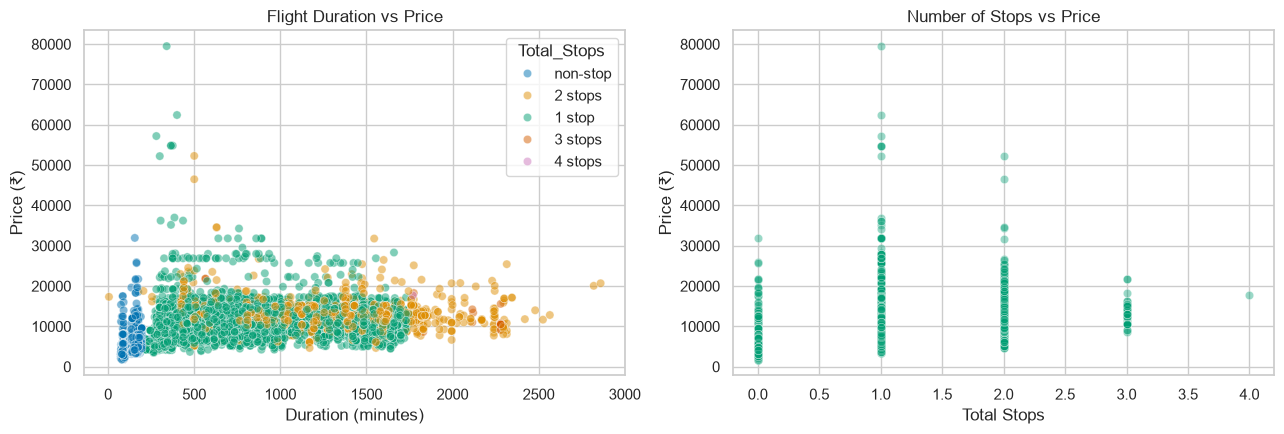

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=eda, x='Duration_mins', y='Price', hue='Total_Stops', alpha=0.5, ax=axes[0], palette='colorblind')
axes[0].set_title('Flight Duration vs Price')
axes[0].set_xlabel('Duration (minutes)'); axes[0].set_ylabel('Price (₹)')

sns.scatterplot(data=eda, x='Total_Stops_num', y='Price', alpha=0.4, ax=axes[1], color='#009E73')
axes[1].set_title('Number of Stops vs Price')
axes[1].set_xlabel('Total Stops'); axes[1].set_ylabel('Price (₹)')
plt.tight_layout()
plt.savefig('scatter_feature_target.png', bbox_inches='tight', dpi=100)
plt.show()

In [15]:
df_clean = df.copy()

# Drop the single row with nulls (Route / Total_Stops) — negligible loss (1 / 10683 rows
df_clean = df_clean.dropna()

# Drop exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows -> {len(df_clean)} rows remain")

# Outlier check on Price using IQR
Q1, Q3 = df_clean['Price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_outliers = ((df_clean['Price'] < lower) | (df_clean['Price'] > upper)).sum()
print(f"IQR bounds: [{lower:.0f}, {upper:.0f}] -> {n_outliers} rows flagged as outliers ({n_outliers/len(df_clean)*100:.1f}%)")

# Strategy: cap (winsorize) rather than delete — these are genuine premium/business-class
# fares, not data errors, and dropping ~2% of rows would bias the model against expensive routes.
df_clean['Price'] = df_clean['Price'].clip(lower=lower, upper=upper)
print("Outliers capped at IQR bounds. New Price range:", df_clean['Price'].min(), "-", df_clean['Price'].max())

Dropped 220 duplicate rows -> 10462 rows remain
IQR bounds: [-5457, 23026] -> 94 rows flagged as outliers (0.9%)
Outliers capped at IQR bounds. New Price range: 1759.0 - 23025.875


In [16]:
# Duration -> total minutes (numeric)
def parse_duration(x):
    h, m = 0, 0
    parts = x.split()
    for p in parts:
        if 'h' in p:
            h = int(p.replace('h', ''))
        elif 'm' in p:
            m = int(p.replace('m', ''))
    return h * 60 + m

df_clean['Duration_mins'] = df_clean['Duration'].apply(parse_duration)

# Date_of_Journey -> day, month (year is constant/uninformative — 2019 only)
journey = pd.to_datetime(df_clean['Date_of_Journey'], format='%d/%m/%Y')
df_clean['Journey_day'] = journey.dt.day
df_clean['Journey_month'] = journey.dt.month

# Dep_Time / Arrival_Time -> hour, minute
dep = pd.to_datetime(df_clean['Dep_Time'], format='%H:%M')
df_clean['Dep_hour'] = dep.dt.hour
df_clean['Dep_min'] = dep.dt.minute

arr = pd.to_datetime(df_clean['Arrival_Time'].str.split(' ').str[0], format='%H:%M')
df_clean['Arrival_hour'] = arr.dt.hour
df_clean['Arrival_min'] = arr.dt.minute

# Total_Stops -> ordinal encoding (stops have a natural order 0 < 1 < 2 < 3 < 4)
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df_clean['Total_Stops_num'] = df_clean['Total_Stops'].map(stop_map)

# Additional_Info: collapse rare categories (<1% frequency) into 'Other' to avoid
# creating one-hot columns that are almost entirely zero
info_counts = df_clean['Additional_Info'].value_counts(normalize=True)
rare_info = info_counts[info_counts < 0.01].index
df_clean['Additional_Info'] = df_clean['Additional_Info'].replace(rare_info, 'Other')

# Engineered flag: is this a red-eye / night departure? (Dep_hour before 6am or after 10pm)
# Justification: red-eye flights are frequently discounted, so this may help the model
# capture a pricing pattern that raw Dep_hour (treated linearly) would miss.
df_clean['Is_Night_Departure'] = ((df_clean['Dep_hour'] < 6) | (df_clean['Dep_hour'] >= 22)).astype(int)

# Drop columns we've now extracted information from, plus Route (high-cardinality,
# largely redundant with Source + Destination + Total_Stops)
df_clean = df_clean.drop(columns=['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration', 'Route', 'Total_Stops'])

print(df_clean.shape)
df_clean.head()

(10462, 14)


,Airline,Source,Destination,Additional_Info,Price,Duration_mins,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Total_Stops_num,Is_Night_Departure
0,IndiGo,Banglore,New Delhi,No info,3897.0,170,24,3,22,20,1,10,0,1
1,Air India,Kolkata,Banglore,No info,7662.0,445,1,5,5,50,13,15,2,1
2,Jet Airways,Delhi,Cochin,No info,13882.0,1140,9,6,9,25,4,25,2,0
3,IndiGo,Kolkata,Banglore,No info,6218.0,325,12,5,18,5,23,30,1,0
4,IndiGo,Banglore,New Delhi,No info,13302.0,285,1,3,16,50,21,35,1,0


In [19]:
TARGET = 'Price'
categorical_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
numeric_cols = ['Duration_mins', 'Journey_day', 'Journey_month', 'Dep_hour', 'Dep_min',
                 'Arrival_hour', 'Arrival_min', 'Total_Stops_num', 'Is_Night_Departure']

df_clean
X = df_clean[categorical_cols + numeric_cols]
y = df_clean[TARGET]

# Train/test split FIRST (80:20) — every encoder/scaler below is fit on X_train only,
# then applied to X_test, to avoid data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Shared preprocessing pipeline (ColumnTransformer): one-hot encode categoricals,
# standard-scale numerics. handle_unknown='ignore' guards against any category
# present in test but not train.
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

preprocessor.fit(X_train)                       # fit on TRAIN ONLY
X_train_proc = preprocessor.transform(X_train)  # transform train
X_test_proc = preprocessor.transform(X_test)    # transform test

feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)) + numeric_cols
print("Processed feature matrix shape:", X_train_proc.shape)

Train: (8369, 13)  Test: (2093, 13)
Processed feature matrix shape: (8369, 36)


In [8]:
from sklearn.tree import DecisionTreeRegressor

In [9]:
results = {}

def evaluate(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"{name:28s}  R2={r2:.4f}   RMSE={rmse:8.1f}   MAE={mae:8.1f}")
    return model

In [11]:
RANDOM_STATE = 42

In [20]:
# 6. Decision Tree Regressor — tune max_depth
dt = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
evaluate('Decision Tree Regressor', dt, X_train_proc, X_test_proc)

Decision Tree Regressor       R2=0.8491   RMSE=  1662.5   MAE=  1037.7


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [21]:
# 7. Random Forest Regressor — ensemble baseline
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
evaluate('Random Forest Regressor', rf, X_train_proc, X_test_proc)

Random Forest Regressor       R2=0.9149   RMSE=  1248.6   MAE=   625.6


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m